# Analising NiSi XRD data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import scipy.signal as signal
from scipy import sparse
from scipy.sparse.linalg import spsolve


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

### read file

In [75]:
# file_path = r"K:\tech_stud\Hager_Lutz\Master\Experiments\Ni-Ge\Stückchen\XRD\05112026_B2_exported.xy"
# file_path = r"C:\Users\lhage\Documents\Seafile\Master\Experiments\Ni-Ge\Stückchen\XRD\05112026_B2_bg_subtracted.xy"
# file_path = r"C:\Users\lhage\Documents\Seafile\Master\Experiments\Ni-Ge\Stückchen\XRD\04272026_B3_900.xy"
file_path = r"C:\Users\Lutz_Laptop\Documents\Seafile\Master\Experiments\Ni-Ge\Stückchen\XRD\05072026_A3_exported.xy"

# data = pd.read_csv(file_path, delimiter="\t", skiprows=2, header=0, names=['Angle', 'Intensity'])
data = pd.read_csv(file_path, delimiter=" ", skiprows=1, header=None, names=['Angle', 'Intensity'])

filename = os.path.basename(file_path)
# name = filename.split("_", 7)[3:7]
# name = " ".join(name)
# print(name)

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2942 entries, 0 to 2941
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Angle      2942 non-null   float64
 1   Intensity  2942 non-null   float64
dtypes: float64(2)
memory usage: 46.1 KB
None


In [77]:
from processXRD import process_XRD_data

processed_data, peak_angles = process_XRD_data(data, roi=False, baseline_params={'lam': 1e7, 'p': 0.0001, 'niter': 15}, peak_params={'prominence': 0.08, 'width': 10})
# processed_data, peak_angles = process_XRD_data(data, roi=False, baseline_params={'lam': 1e7, 'p': 0.0001, 'niter': 10}, peak_params={'prominence': 0.04, 'width': 5})
# processed_data, peak_angles = process_XRD_data(data, roi=True, roi_start=64.5, roi_end=66.5, baseline_params={'lam': 1e7, 'p': 0.0001, 'niter': 10}, peak_params={'prominence': 0.2, 'width': 20})

peak_angles = peak_angles.to_numpy()

c:\Users\Lutz_Laptop\Documents\VS_Code\Master_data\XRD\processXRD.py:17: SparseEfficiencyWarning:

spsolve requires A be CSC or CSR matrix format



### plot basic spectra starting point

C:\Users\Lutz_Laptop\AppData\Local\Temp\ipykernel_7944\800648278.py:15: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



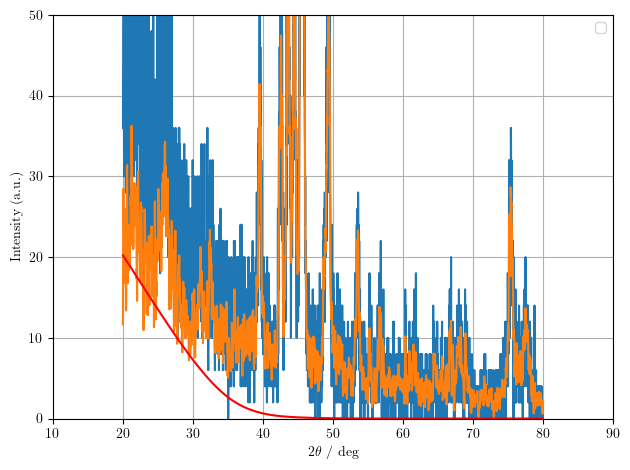

In [78]:
fig, ax = plt.subplots()
ax.plot(data['Angle'], data['Intensity'])
# ax.plot(processed_data['Angle'], processed_data['corrected'])
ax.plot(processed_data['Angle'], processed_data['filtered'])
# ax.plot(processed_data['Angle'], processed_data['baseline'])
# ax.semilogy(processed_data['Angle'], processed_data['filtered'], color='green')
ax.plot(processed_data['Angle'], processed_data['baseline'], color='red')
# ax.axes.get_yaxis().set_ticklabels([])
plt.xlim(10, 90)
plt.ylim(0, 50)

plt.gca().set_ylim(bottom=0)
plt.xlabel("$2\\theta$ / deg")
plt.ylabel("Intensity (a.u.)")
plt.legend(loc='upper right')
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'{os.path.join(os.path.dirname(file_path), name)}_processed.pdf', dpi=300)
plt.show()

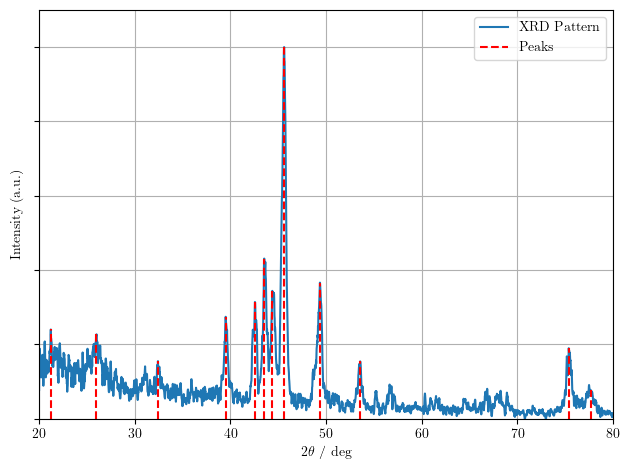

In [81]:
fig, ax = plt.subplots()

ax.plot(processed_data['Angle'], processed_data['intensity_norm'], label=f'XRD Pattern')
plt.vlines(peak_angles, ymin=0, ymax=processed_data[processed_data['Angle'].isin(peak_angles)]['intensity_norm'].values, color='red', linestyle='--', label='Peaks')
ax.axes.get_yaxis().set_ticklabels([])
plt.xlim(20, 80)
plt.ylim(0, 1.1)
plt.gca().set_ylim(bottom=0)
plt.xlabel("$2\\theta$ / deg")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}_bessel.pdf', dpi=500)
plt.show()

In [ ]:
# print(processed_data.loc[(processed_data['Angle']>77)&(processed_data['Angle']<78), 'Angle'])

In [33]:
print(peak_angles)

[21.224  23.0804 25.9976 32.4236 39.5024 42.5624 43.5416 44.378  45.6224
 49.3556 53.558  56.6384 75.3656]


In [80]:
# peak_angles = np.append(peak_angles, 75.2432)
# peak_angles = peak_angles[1:]
peak_angles = np.append(peak_angles, 77.6708)
peak_angles = np.delete(peak_angles, [1,11])

# expermamenting with auto labeling

In [23]:
def auto_label_peaks(exp_peaks, ref_dict, tolerance=0.3):
    """Matches experimental peak positions to the best theoretical phase and HKL."""
    results = [] # Will store strings like "Ni (111)"

    for p_exp in exp_peaks:
        best_match = None
        highest_ref_int = -1
        
        for phase, data in ref_dict.items():
            ref_thetas = np.array(data['two_theta'])
            ref_intensities = np.array(data['intensity'])
            ref_hkls = data['hkl']
            
            diffs = np.abs(ref_thetas - p_exp)
            mask = diffs <= tolerance
            
            if np.any(mask):
                # Find the strongest theoretical peak within the tolerance
                idx = np.where(mask)[0][np.argmax(ref_intensities[mask])]
                current_max_int = ref_intensities[idx]
                
                if current_max_int > highest_ref_int:
                    highest_ref_int = current_max_int
                    hkl = ref_hkls[idx]
                    # Format as Phase (hkl)
                    best_match = f"{data['phase']} {hkl}"
        
        results.append(best_match)
    return results

In [24]:
# reference_folder = r"C:\Users\lhage\Documents\Seafile\Master\Experiments\Ni-Si\Stückchen\XRD\CIFs\Exports"
reference_folder = r"C:\Users\Lutz_Laptop\Documents\Seafile\Master\Experiments\Ni-Si\Stückchen\XRD\CIFs\Exports"

all_references = {}
for file in os.listdir(reference_folder):
    filepath = os.path.join(reference_folder, file)

    columns = [
        'h', 'k', 'l',
        'd_A',
        'F_real',
        'F_imag',
        'F_abs',
        '2theta',
        'I',
        'M',
        'ID_lambda',
        'Phase']

    cif_result = pd.read_csv(filepath, sep=r'\s+', skiprows=1, names=columns)

    cif_result['hkl'] = ('(' + cif_result['h'].astype(str) + cif_result['k'].astype(str) + cif_result['l'].astype(str) + ')')

    name = os.path.splitext(file)[0]
    # name_parts = file.split("-", 2)[0:2]
    # name = f'{name_parts[0]} {name_parts[1]}'

    all_references[name] = {
        'phase': file.split("-", 2)[0],
        'two_theta': cif_result['2theta'].tolist(),
        'intensity': cif_result['I'].tolist(),
        'hkl': cif_result['hkl'].tolist()}
    
print(all_references.keys())

dict_keys(['$NiGe$-Pbnm-9008935', '$NiSi$-P213-2300376', '$NiSi$-Pnma-1532040', '$Ni_2Si$-P63_22-1523551', '$Ni_2Si$-Pnma-2310976', '$Ni_{31}Si_{12}$-P321-2106046', '$SiC$-P3m1-2310851'])


['$Ni_{31}Si_{12}$ (102)', None, '$Ni_2(Si,Ge)$ (111)', '$Ni_2(Si,Ge)$ (112)', '$Ni_2(Si,Ge)$ (103)', '$Ni_2(Si,Ge)$ (210)', '$Ni_2(Si,Ge)$ (202)', '$Ni_2(Si,Ge)$ (102)', '$Ni_2(Si,Ge)$ (020)', '$Ni_2(Si,Ge)$ (203)', '$Ni_2(Si,Ge)$ (223)', '$Ni_{31}Si_{12}$ (0010)']


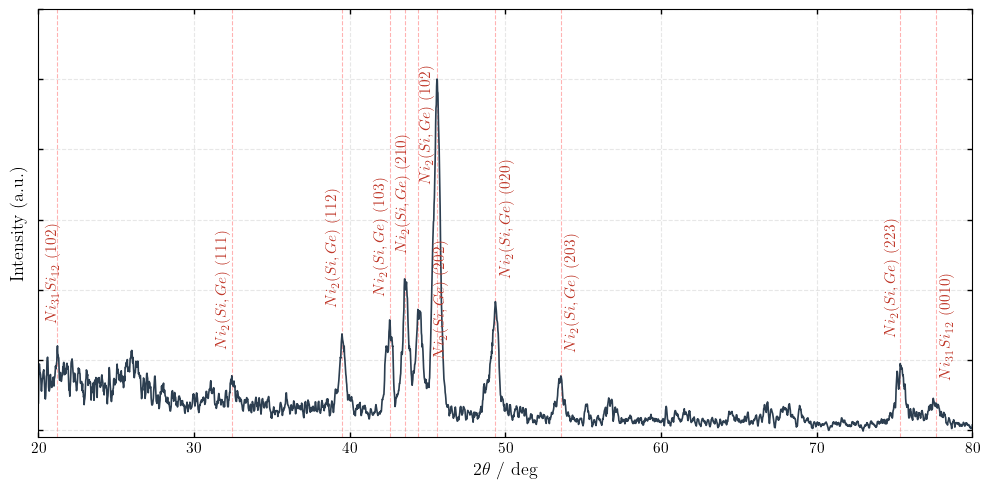

In [86]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 5))

# Plot experimental data
ax.plot(processed_data['Angle'], processed_data['intensity_norm'], 
        color='#2c3e50', lw=1.2, zorder=2)

# Identify labels for peaks
labels = auto_label_peaks(peak_angles, all_references, tolerance=0.3)
labels = [
    label.replace('Ni_2Si', 'Ni_2(Si,Ge)') if label is not None else None
    for label in labels
]
labels = [label.replace('$NiGe$ (211)', '$Ni_2(Si,Ge)$ (202)') if label else None for label in labels]
labels = [label.replace('$NiGe$ (002)', '$Ni_2(Si,Ge)$ (203)') if label else None for label in labels]
# labels = [label.replace('$Ni_{31}Si_{12}$ (0010)', '$Ni_2(Si,Ge)$ (004)') if label else None for label in labels]
# labels = [label.replace('$NiSi$ (211)', '$Ni_2(Si,Ge)$ (113)') if label else None for label in labels]
print(labels)      

texts = []
for pos, label in zip(peak_angles, labels):
    if label:
        idx = np.abs(processed_data['Angle'] - pos).argmin()
        peak_height = processed_data['intensity_norm'].iloc[idx]
        
        ax.axvline(pos, color='red', linestyle='--', alpha=0.3, lw=0.8, zorder=1)
        
        t = ax.text(pos, peak_height + 0.02, label, 
                    rotation=90, fontsize=11, 
                    color='#c0392b', weight='bold',
                    va='bottom', ha='center', zorder=10)
        texts.append(t)

ax.set_ylim(-0.02, 1.2) 
adjust_text(texts, only_move={'points':'y', 'text':'xy'}, add_objects=[ax.lines[0]])


ax.set_yticklabels([])
# ax.set_xlim(10, 90)
ax.set_xlim(20, 80)
ax.set_ylim(-0.02, 1.2) # Increased upper limit to give labels room to breathe

ax.tick_params(axis='both', which='both', direction='in', 
                top=True, right=True, 
                width=1.0, labelsize=11)

ax.set_xlabel(r"$2\theta$ / deg", fontsize=13)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=13)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

plt.tight_layout()
# plt.savefig(f'{os.path.join(os.path.dirname(file_path), "B2_20nm_850")}_labeled.pdf', dpi=300)
plt.show()

In [84]:
import plotly.graph_objects as go
fig = go.Figure()

# 1. Plot the Experimental Data (the black line)
fig.add_trace(go.Scatter(
    x=processed_data['Angle'], 
    y=processed_data['intensity_norm'],
    mode='lines',
    name='Experimental Data',
    line=dict(color='black', width=1.5)
))

symbols = ['circle', 'square', 'triangle-up', 'diamond', 'star']

for i, (phase, ref) in enumerate(all_references.items()):
    # if ref['intensity'] > 5:
    # We plot these at a fixed height or relative to your data
    # Here, we plot them at y=1.05 (just above the normalized data)
    fig.add_trace(go.Scatter(
        x=ref['two_theta'],
        y=[1.05] * len(ref['two_theta']), # Align them in a row at the top
        mode='markers',
        name=phase,
        marker=dict(symbol=symbols[i % len(symbols)], size=10),
        hovertemplate=f"<b>{phase}</b><br>2θ: %{{x}}<br>Ref Intensity: %{{text}}%<extra></extra>",
        text=ref['intensity'] # Store relative intensity in hover text
    ))

# 3. Scientific Styling
fig.update_layout(
    yaxis_range=[0, 1.2],
    xaxis_range=[20, 80],
    title="Phase Identification:",
    xaxis_title="2θ (degrees)",
    yaxis_title="Intensity (Normalized)",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99)
)

fig.show()

{'$SiC$': array([0.993248, 0.906157, 0.143936, 1.      ]), '$Ni_2(Si,Ge)$': array([0.128729, 0.563265, 0.551229, 1.      ]), '$Ni_{31}Si_{12}$': array([0.267004, 0.004874, 0.329415, 1.      ])}


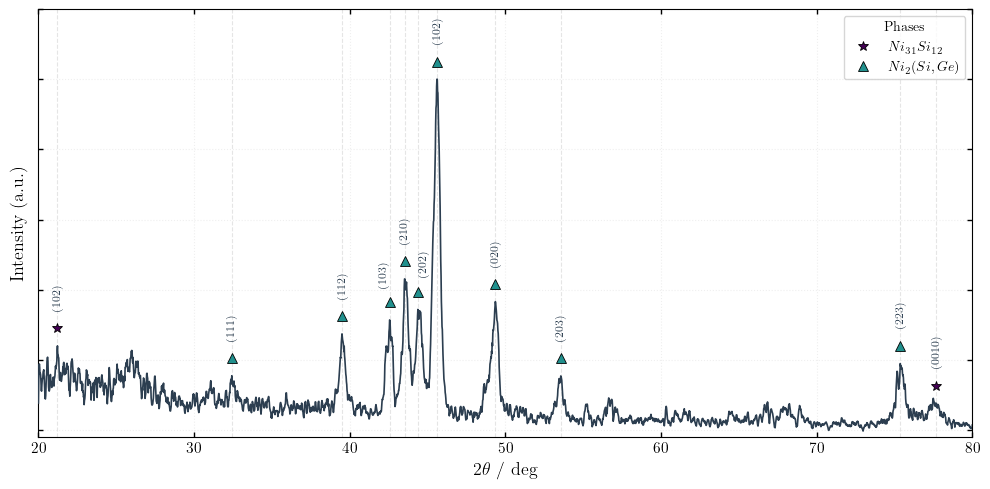

In [ ]:
marker_map = {
    '$SiC$': 'o',            
    '$Ni_2(Si,Ge)$': '^',     
    '$Ni_{31}Si_{12}$': '*' ,  
    # '$NiGe$': 'v',            
    # '$NiSi_2$': 'o',     
    # '$NiSi$': 's',       
}

# Generate color map based on phases
phase_keys = list(marker_map.keys())
colors = plt.get_cmap('viridis_r')(np.linspace(0, 1, len(phase_keys)))
color_map = dict(zip(phase_keys, colors))
print(color_map)

fig, ax = plt.subplots(figsize=(10, 5))

# Plot experimental data
ax.plot(processed_data['Angle'], processed_data['intensity_norm'], 
        color='#2c3e50', lw=1.2, zorder=3)

# Identify labels for peaks
labels = auto_label_peaks(peak_angles, all_references, tolerance=0.3)
labels = [
    label.replace('Ni_2Si', 'Ni_2(Si,Ge)') if label is not None else None
    for label in labels
]
labels = [label.replace('$NiGe$ (211)', '$Ni_2(Si,Ge)$ (202)') if label else None for label in labels]
labels = [label.replace('$NiGe$ (002)', '$Ni_2(Si,Ge)$ (203)') if label else None for label in labels]
# labels = [label.replace('$NiGe$ (002)', '$Ni_2(Si,Ge)$ (203)') if label else None for label in labels]labels = [label.replace('$Ni_{31}Si_{12}$ (0010)', '$Ni_2(Si,Ge)$ (004)') if label else None for label in labels]
# labels = [label.replace('$NiSi$ (211)', '$Ni_2(Si,Ge)$ (113)') if label else None for label in labels]
# print(labels)      

texts = []
for pos, full_label in zip(peak_angles, labels):
    if full_label:
        # Extract Phase and HKL Phase (Structure) (hkl)
        phase = full_label.split(' ',)[0].strip()
        hkl = f"({full_label.split('(')[-1]}" 
        
        idx = np.abs(processed_data['Angle'] - pos).argmin()
        peak_height = processed_data['intensity_norm'].iloc[idx]
        
        ax.axvline(pos, color='gray', linestyle='--', alpha=0.2, lw=0.8, zorder=1)
        
        ax.plot(pos, peak_height + 0.05, marker=marker_map[phase], 
                color=color_map[phase], markersize=7, linestyle='None', 
                markeredgecolor='black', markeredgewidth=0.6,
                label=phase, zorder=4)
        
            
        # hkl Text
        t = ax.text(pos, peak_height + 0.08, hkl, 
                    rotation=90, fontsize=8, 
                    color='#2c3e50', va='bottom', ha='center')
        texts.append(t)

# 4. Clean up the Legend (remove duplicates)
handles, legend_labels = ax.get_legend_handles_labels()
by_label = dict(zip(legend_labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Phases", 
          loc='upper right', frameon=True, fontsize=10)

ax.set_ylim(-0.02, 1.2)
# Adjust text to prevent overlapping
if texts:
    adjust_text(texts, only_move={'points':'y', 'text':'xy'}, add_objects=[ax.lines[0]])

# Final formatting
ax.set_xlim(20, 80)
ax.set_ylim(-0.02, 1.2)
ax.set_yticklabels([])
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, width=1.0, labelsize=11)
ax.set_xlabel(r"$2\theta$ / deg", fontsize=13)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=13)
ax.grid(True, linestyle=':', alpha=0.2, zorder=1)

plt.tight_layout()
# plt.savefig(f'{os.path.join(os.path.dirname(file_path), "A3_60nm_900")}_markers.pdf', dpi=300)
plt.show()